#### Lib are Imported

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### CSV File is Imported

In [282]:
dataset=pd.read_csv('../DataSets/messy_expense_v2.csv')

##### Info about all the Data Column is collected to check no.of.null values and dtypes

In [283]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          550 non-null    object
 1   Category      535 non-null    object
 2   Payment_Mode  565 non-null    object
 3   Amount        536 non-null    object
 4   Description   493 non-null    object
dtypes: object(5)
memory usage: 22.2+ KB


##### To display no.of.null Cells

In [284]:
print(dataset.isnull().sum())

Date            15
Category        30
Payment_Mode     0
Amount          29
Description     72
dtype: int64


##### Cleaned all the Date Formats and brought them into Single format for better Categorization of Expense

In [285]:
dataset['Date']=pd.to_datetime(dataset['Date'],format='mixed',dayfirst=True,errors='coerce')
dataset.dropna(subset=['Date'],inplace=True)
dataset.dropna(subset=['Category'],inplace=True)

##### Check for a Negative Expense and remove it

In [286]:
dataset['Category'] = dataset['Category'].fillna('Unknown')
dataset['Category'] = dataset['Category'].str.strip().str.title()
dataset['Payment_Mode']=dataset['Payment_Mode'].str.strip().str.title()

##### Based on the month.no Specifically assigned the Month Name

In [287]:
dataset['Month']=dataset['Date'].dt.month_name()

##### If some Amount are not mentioned then first try to find out the category then take it's Avg and insert the Avg in Null Cell

In [288]:
dataset['Amount'] = pd.to_numeric(dataset['Amount'], errors='coerce')
dataset['Amount'] = dataset['Amount'].fillna(dataset.groupby('Category')['Amount'].transform('mean'))
dataset['Amount'] = dataset['Amount'].fillna(dataset['Amount'].mean())
dataset=dataset[dataset['Amount']>0]

##### Get Category-Wise expenses and display the most Expense send Category from Top to Bottom

In [289]:
category_expense=dataset.groupby(['Category'])['Amount'].sum().sort_values(ascending=False)

##### Get Monthly Expense in Order

In [290]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_expense=dataset.groupby(['Month'])['Amount'].sum().sort_values(ascending=False)
monthly_expense=monthly_expense.reindex(month_order)

##### Check which Payment method was used how many TIMES and Amount spend by each Method

In [291]:
payment_method=dataset.groupby(['Payment_Mode'])['Amount'].sum().sort_values(ascending=False)
payment_count=dataset['Payment_Mode'].value_counts()

In [292]:
daily_expense=dataset.groupby(['Date'])['Amount'].sum().sort_values(ascending=False)

##### Display Category Wise Expense

In [293]:
print(category_expense)
print("\n")
print("Highest Spend on",category_expense.idxmax()," : ₹",category_expense.max())
print("Lowest Spend on",category_expense.idxmin()," : ₹",category_expense.min())

Category
Food             346363.975455
Shopping         276383.279298
Travel           257826.022759
Entertainment    253025.940317
Utilities        251525.608214
Health           235449.000968
Transport        231426.385345
Education        141281.518788
Name: Amount, dtype: float64


Highest Spend on Food  : ₹ 346363.97545454546
Lowest Spend on Education  : ₹ 141281.5187878788


##### Diplay Monthly Expense

In [294]:
print(monthly_expense)
print("\n")
print("Highest Expenses is in Month of",monthly_expense.idxmax()," : ₹",monthly_expense.max())
print("Lowest Expenses is in Month of",monthly_expense.idxmin()," : ₹",monthly_expense.min())

Month
January      154169.839700
February     184688.737229
March        147565.026987
April        163378.006552
May          206708.823036
June         179569.302234
July         140576.695269
August       178227.089287
September    132799.305682
October      138137.942227
November     183590.383353
December     183870.579587
Name: Amount, dtype: float64


Highest Expenses is in Month of May  : ₹ 206708.82303571427
Lowest Expenses is in Month of September  : ₹ 132799.30568181816


##### Display Payment Mode Count and Amount Spend

In [295]:
print(payment_method)
print("\n")
print("Total No. of Payments made :",payment_count)

Payment_Mode
Net Banking    488612.212768
Credit Card    444816.431699
Upi            426622.136402
Cash           349630.863530
Debit Card     283600.086745
Name: Amount, dtype: float64


Total No. of Payments made : Payment_Mode
Upi            115
Credit Card    113
Net Banking    112
Cash            93
Debit Card      67
Name: count, dtype: int64


In [296]:
print("Top 5 highest spending days:")
print(daily_expense.sort_values(ascending=False).head())
print("\nTop 5 lowest spending days:")
print(daily_expense.sort_values().head())


Top 5 highest spending days:
Date
2024-02-03    37924.230000
2024-12-04    34422.190000
2024-10-27    30334.248097
2024-05-27    23383.580000
2024-11-18    22198.630000
Name: Amount, dtype: float64

Top 5 lowest spending days:
Date
2024-10-25     91.29
2024-03-09    166.72
2024-12-08    312.35
2024-07-16    413.82
2024-10-05    527.68
Name: Amount, dtype: float64


##### Display some Statstical Data about Expenses

In [297]:
print("Average Amount Spend Daily :", dataset['Amount'].mean())
print("Median:", dataset['Amount'].median())
print("Most Frequent Amount Spend", dataset['Amount'].mode()[0])
print("Std Dev:", dataset['Amount'].std())
print("Variance:", dataset['Amount'].var())
print("Min:", dataset['Amount'].min())
print("Max:", dataset['Amount'].max())
print("75th Percentile Spend:", np.percentile(dataset['Amount'], 75))

Average Amount Spend Daily : 3986.563462287212
Median: 3917.995
Most Frequent Amount Spend 3588.4856818181815
Std Dev: 2154.8458027577544
Variance: 4643360.433662711
Min: 64.82
Max: 7994.95
75th Percentile Spend: 5632.545


In [298]:
print("Key Insights:")
print(f"1. Highest spending category: {category_expense.idxmax()} ({category_expense.max():.2f})")
print(f"2. Lowest spending category: {category_expense.idxmin()} ({category_expense.min():.2f})")
print(f"3. Most used payment method: {payment_count.idxmax()} ({payment_count.max()} transactions)")
print(f"4. Average daily spend: {daily_expense.mean():.2f}")


Key Insights:
1. Highest spending category: Food (346363.98)
2. Lowest spending category: Education (141281.52)
3. Most used payment method: Upi (115 transactions)
4. Average daily spend: 7274.75


##### Plot Graph for Monthly_Expense and it's Month

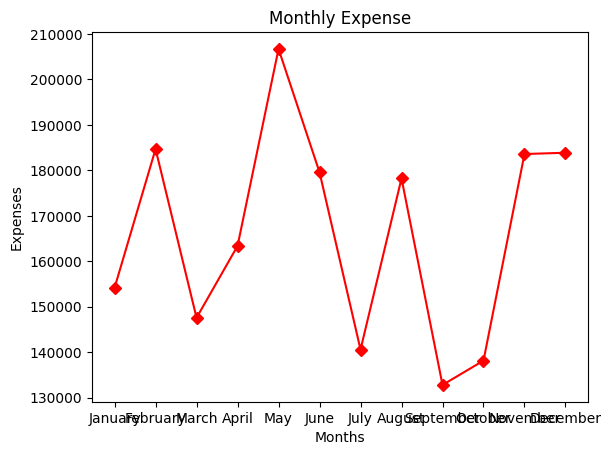

In [299]:
plt.plot(monthly_expense.index,monthly_expense,'D-r')
plt.xlabel("Months")
plt.ylabel('Expenses')
plt.title("Monthly Expense")
plt.show()

##### Plot Category Wise Expense

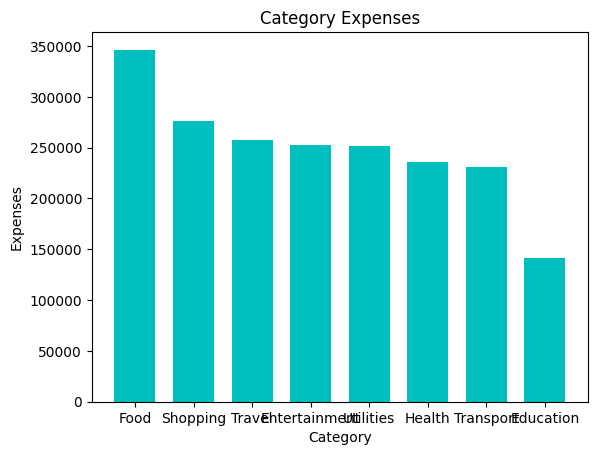

In [300]:
plt.bar(category_expense.index,category_expense,width=0.7,color='c')
plt.ylabel("Expenses")
plt.xlabel("Category")
plt.title("Category Expenses")
plt.show()

##### Plot the Payment Method

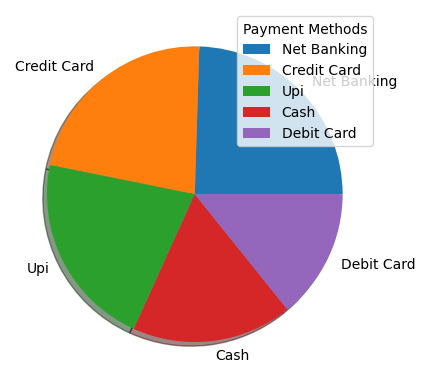

In [301]:
plt.pie(payment_method,labels=payment_method.index,shadow=True)
plt.legend(title="Payment Methods")
plt.show()

##### Save to a New File

In [302]:
dataset.to_csv(r'../DataSets/messy_claude_clean2.csv', index=False)